In [1]:
import os
import sys
import glob
import pandas as pd
sys.path.append("../utils")

In [2]:
def concat_ndvi_files(folder_path):
    """
    Input folder path to this function to concatenate all *.csv files by 'inspection_id'.
    This function is designed only for output files from the notebook `ndvi_calculate.ipynb`.

    Example usage: concatenated = concat_ndvi_files("/capstone/wildfire_prep/ryan/data-preparation/code/07_ndvi_pystac/ndvi_files")
    """
    # read all csv files
    csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    # read each, selecting only the two columns we need
    df_list = [
        pd.read_csv(fp)[["inspection_id", "mean_ndvi_2month_prior"]] for fp in csv_files
    ]

    # stack them and reset the index
    concatenated = pd.concat(df_list, axis=0, ignore_index=True)
    return concatenated


In [3]:
concatenated = concat_ndvi_files(
    "/capstone/wildfire_prep/data/ndvi_pystac_files/ndvi_2month_prior"
)

In [4]:
print(f"Shape of concatenated data:", concatenated.shape)
print(f"Number of NA Values in data:", concatenated.mean_ndvi_2month_prior.isna().sum())

n_clouds = (concatenated["mean_ndvi_2month_prior"] < -0.1).sum()
print(f"{n_clouds} values below -0.1 (likely clouds)")

Shape of concatenated data: (67580, 2)
Number of NA Values in data: 97
0 values below -0.1 (likely clouds)


In [8]:
concatenated.to_csv(
    "/capstone/wildfire_prep/data/PUZZLE_PIECES/inspection_id_ndvi_2month_prior.csv",
    index=False,
)

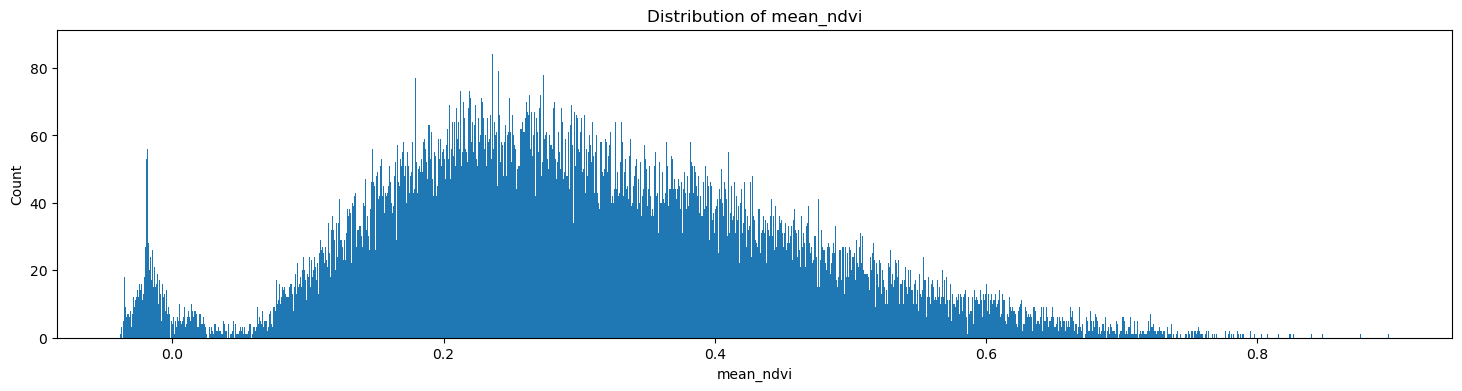

In [6]:
import matplotlib.pyplot as plt

values = concatenated["mean_ndvi_2month_prior"].dropna()

plt.figure(figsize = (18, 4))
plt.hist(values, bins=3000)
plt.xlabel("mean_ndvi")
plt.ylabel("Count")
plt.title("Distribution of mean_ndvi")
plt.show()


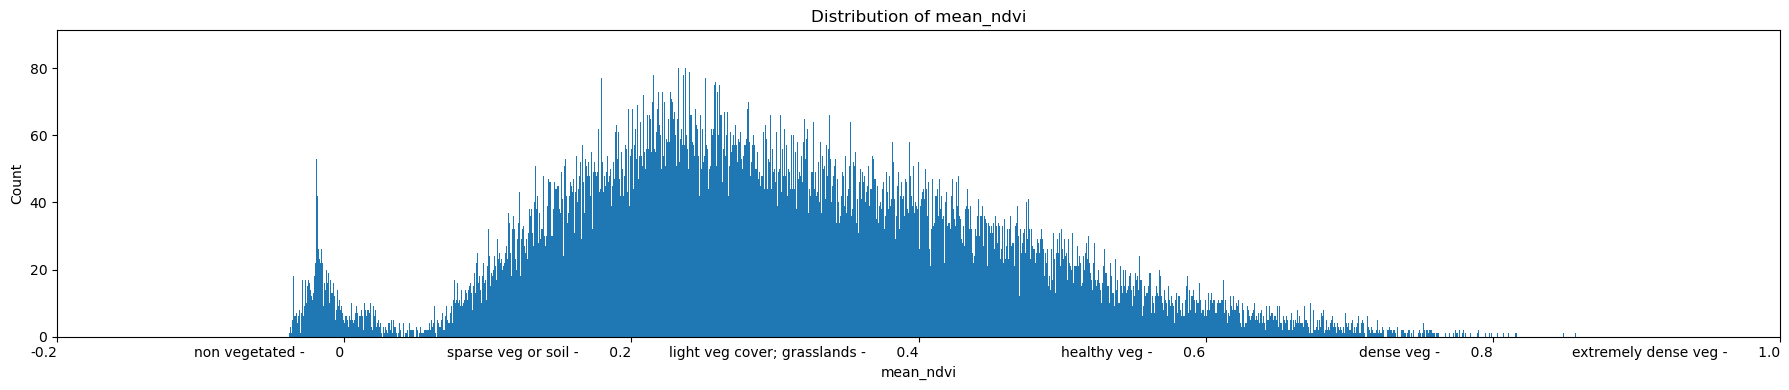

In [7]:
values = concatenated["mean_ndvi_2month_prior"].dropna()

plt.figure(figsize=(18, 4))
plt.hist(values, bins=3000)
plt.xlabel("mean_ndvi")
plt.ylabel("Count")
plt.title("Distribution of mean_ndvi")

positions = plt.xticks()[0]

tick_labels = [
    "-0.2",
    "non vegetated -       0",
    "sparse veg or soil -       0.2",
    "light veg cover; grasslands -       0.4",
    "healthy veg -       0.6",
    "dense veg -       0.8",
    "extremely dense veg -       1.0",
]

plt.xticks(positions, tick_labels, ha="right")

plt.tight_layout()
plt.show()
